In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from util import load_experiment, random_quantiles

In [2]:
model_12hr, dataset, config = load_experiment('9e261057-b3c0-4cd9-81ed-d902d1b6b9f7', '../../data/processed/dataset_clean_no-outliers.csv')
model_24hr, _, _ = load_experiment('2f9769b2-6c71-4f01-badd-bb1469e4c590', '../../data/processed/dataset_clean.csv')

Time steps to predict: 24
[0.359662   0.5083245  0.5846548  0.38561556 0.8355197  0.71721077
 0.68378174 0.4141604  0.59949577 0.3479853  0.73458636 0.49085894
 0.6430682  0.48515907 0.66153276 0.83099246 0.8704592  0.6268486
 0.7577559  0.6877284  0.6752014  0.8031533  0.7326672  0.9630662 ]
[0.406584   0.5344955  0.5868711  0.498326   0.81499445 0.7405184
 0.738109   0.5918243  0.6815571  0.55554754 0.76014036 0.6299341
 0.7203222  0.6382377  0.74027205 0.8431316  0.86672616 0.732573
 0.82302415 0.79762805 0.7768508  0.84806705 0.8104697  0.9462616 ]


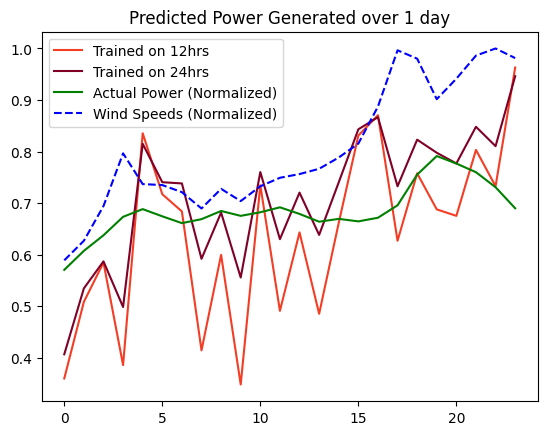

Time steps to predict: 168
[ 0.5110935   0.5103427   0.775157    0.7995403   0.534935    0.84324014
  0.37577298  0.81455076  0.7432492   0.75938165  0.6993067   0.71926355
  0.7213551   0.631588    0.75054026  0.64906645  0.65794647  0.9584565
  0.52383924  0.826715    0.8970125   0.6378342   0.810254    0.8523023
  0.81892335  0.8745568   0.8007362   0.50032747  0.87251437  0.79323125
  0.8064308   0.53571415  0.36926737  0.5641098   0.15865353  0.40317574
  0.5587959   0.4425818   0.567474    0.16935816  0.03317311  0.5747622
  0.439051    0.680284    0.28040555  0.41328737  0.26145872  0.2763957
  0.23963585  0.36094436  0.76371264  0.7988142   0.817184    0.7180439
  0.769168    0.6663703   0.29617527  0.7986971   0.72499096  0.48336723
  0.4355102   0.14286122  0.20626423  0.58004355  0.29136714  0.4991397
  0.5481498   0.20336673  0.4483433   0.18653086  0.59367883  0.65492284
  0.2857732   0.4296939   0.39182654  0.4599544   0.7926128   0.67252576
  0.33230868  0.47050098  0.11

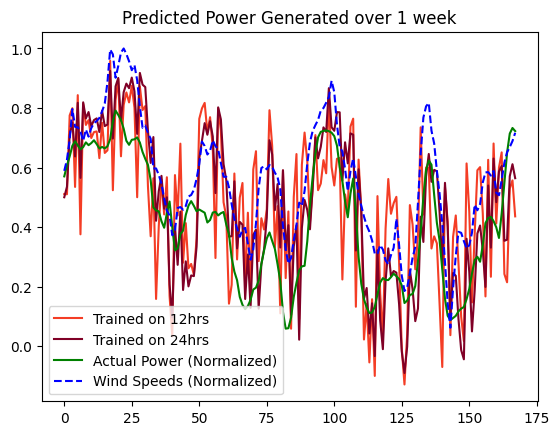

Time steps to predict: 720
[ 0.7403456   0.16900209  0.7684909   0.5971837   0.360507    0.45592478
  0.5722256   0.4933081   0.84347844  0.6293614   0.7328234   0.59995663
  0.69469464  0.5419996   0.62123454  0.42811766  0.7172029   0.908178
  0.5664357   0.8532444   0.5529146   0.7510613   0.55930996  0.95091176
  0.8560239   0.8508239   0.57483506  0.45565274  0.8597857   0.81549656
  0.6885085   0.5813011   0.3272521   0.6151304   0.41495672  0.17300305
  0.42137828  0.50133014  0.6494627   0.1314269   0.62696695  0.29381323
  0.61940134  0.1859028   0.26183835  0.6538731   0.5460551   0.2608708
  0.31269667  0.5729606   0.37711486  0.5547739   0.71203125  0.7074268
  0.6416856   0.8083185   0.5156299   0.45522532  0.708542    0.26039717
  0.40809205  0.41880068  0.18092757  0.29180476 -0.0135374  -0.05342171
  0.05828232  0.10347512  0.5979936   0.3134363   0.21963957  0.64013875
  0.6358783   0.49763623  0.6848781   0.6764927   0.7864274   0.51837325
  0.5134132   0.71090734  0.

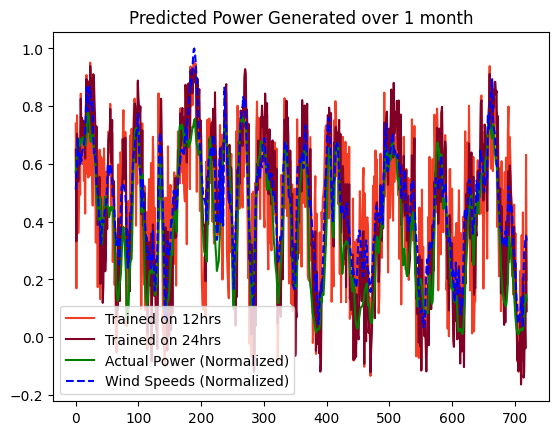

In [3]:
(speed, power) = dataset

models = [model_12hr, model_24hr]
model_labels = ['Trained on 12hrs', 'Trained on 24hrs']

scales = ['1 day', '1 week', '1 month']
upper_bounds = [24, 24 * 7, 24 * 30]

M = len(models)

for i in range(len(scales)):
    scale = scales[i]
    T = upper_bounds[i]
    x = np.arange(0, T)

    input = speed[:T].unsqueeze(0)
    target = power[:T]

    norm_speed = input.squeeze() / torch.max(input)
    cmap = plt.get_cmap('YlOrRd', M + 2)
    print(f'Time steps to predict: {T}')
    # Use same quantiles for all models to ensure "fairness" in visualizing predictions
    quantiles = random_quantiles(size=(T), low=0.01, high=0.99)
    for j in range(M):
        model = models[j]
        label = model_labels[j]
        predicted_power = model(input, quantiles).detach().cpu().numpy().squeeze()
        print(predicted_power)
        plt.plot(x, predicted_power, color=cmap(j+2), label=label)
    plt.plot(x, target, 'g', label='Actual Power (Normalized)')
    plt.plot(x, norm_speed, '--b', label='Wind Speeds (Normalized)')
    plt.title(f'Predicted Power Generated over {scale}')
    plt.legend()
    plt.show()

[]

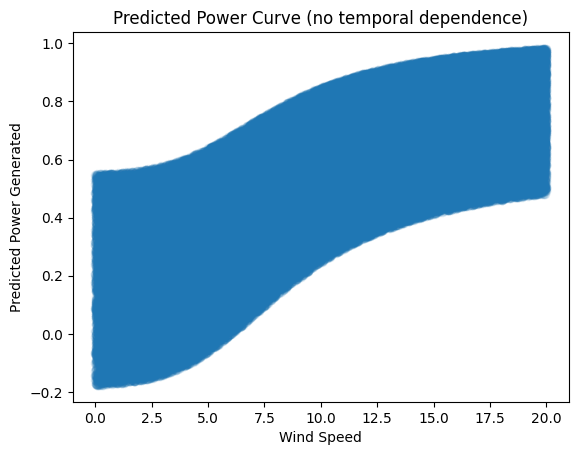

In [ ]:
N = 100000
random_wind_speeds = np.random.uniform(0, 20, N)

preds = []
for speed in random_wind_speeds:
    input = torch.tensor([speed], dtype=torch.float).unsqueeze(0)
    alpha = random_quantiles(1, 0.01, 0.99)
    pred = model_12hr(input, alpha).detach().cpu().numpy().squeeze()
    preds.append(pred)

N = 100000
random_wind_speeds = np.linspace(0, 20, N)
print(random_wind_speeds.shape)

input = torch.tensor(random_wind_speeds, dtype=torch.float).unsqueeze(0)
alpha = random_quantiles(N, 0.01, 0.99)
preds = model_12hr(input, alpha).detach().cpu().numpy().squeeze()
print(preds.shape)
plt.scatter(random_wind_speeds, preds, alpha=0.1)
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (with temporal dependence)')
plt.plot()

plt.scatter(random_wind_speeds, preds, alpha=0.1)
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (no temporal dependence)')
plt.plot()

(100000,)
(100000,)


[]

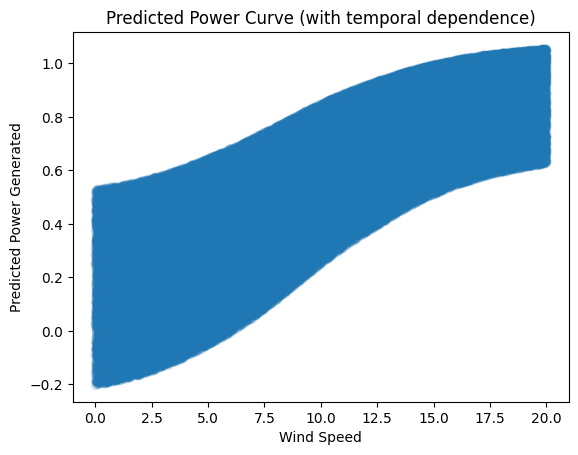

In [23]:
N = 100000
random_wind_speeds = np.linspace(0, 20, N)
print(random_wind_speeds.shape)

input = torch.tensor(random_wind_speeds, dtype=torch.float).unsqueeze(0)
alpha = random_quantiles(N, 0.01, 0.99)
preds = model_12hr(input, alpha).detach().cpu().numpy().squeeze()
print(preds.shape)
plt.scatter(random_wind_speeds, preds, alpha=0.1)
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (with temporal dependence)')
plt.plot()